In [4]:
import pandas as pd

# Load CSV file
df = pd.read_csv("/powerconsumption.csv")

# Display first 5 rows
print(df.head())

        Datetime  Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
0  1/1/2017 0:00        6.559      73.8      0.083                0.051   
1  1/1/2017 0:10        6.414      74.5      0.083                0.070   
2  1/1/2017 0:20        6.313      74.5      0.080                0.062   
3  1/1/2017 0:30        6.121      75.0      0.083                0.091   
4  1/1/2017 0:40        5.921      75.7      0.081                0.048   

   DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
0         0.119             34055.69620             16128.87538   
1         0.085             29814.68354             19375.07599   
2         0.100             29128.10127             19006.68693   
3         0.096             28228.86076             18361.09422   
4         0.085             27335.69620             17872.34043   

   PowerConsumption_Zone3  
0             20240.96386  
1             20131.08434  
2             19668.43373  
3             18899.27711  
4     

In [5]:
df.shape

(52416, 9)

In [6]:
df.dtypes

,0
Datetime,object
Temperature,float64
Humidity,float64
WindSpeed,float64
GeneralDiffuseFlows,float64
DiffuseFlows,float64
PowerConsumption_Zone1,float64
PowerConsumption_Zone2,float64
PowerConsumption_Zone3,float64


In [7]:
df.isnull().sum()

,0
Datetime,0
Temperature,0
Humidity,0
WindSpeed,0
GeneralDiffuseFlows,0
DiffuseFlows,0
PowerConsumption_Zone1,0
PowerConsumption_Zone2,0
PowerConsumption_Zone3,0


In [8]:
df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [9]:
df["Total_Consumption"] = (
    df["PowerConsumption_Zone1"] +
    df["PowerConsumption_Zone2"] +
    df["PowerConsumption_Zone3"]
)

In [10]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

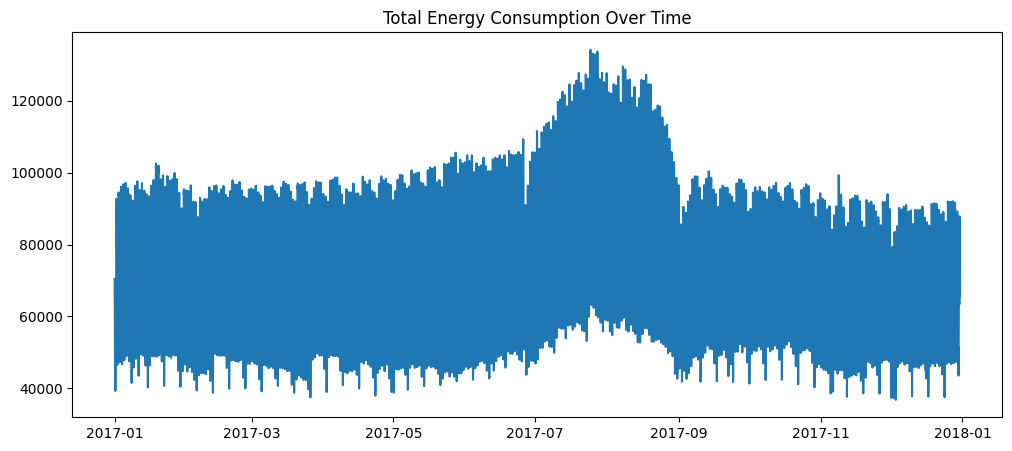

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Total_Consumption"])
plt.title("Total Energy Consumption Over Time")
plt.show()

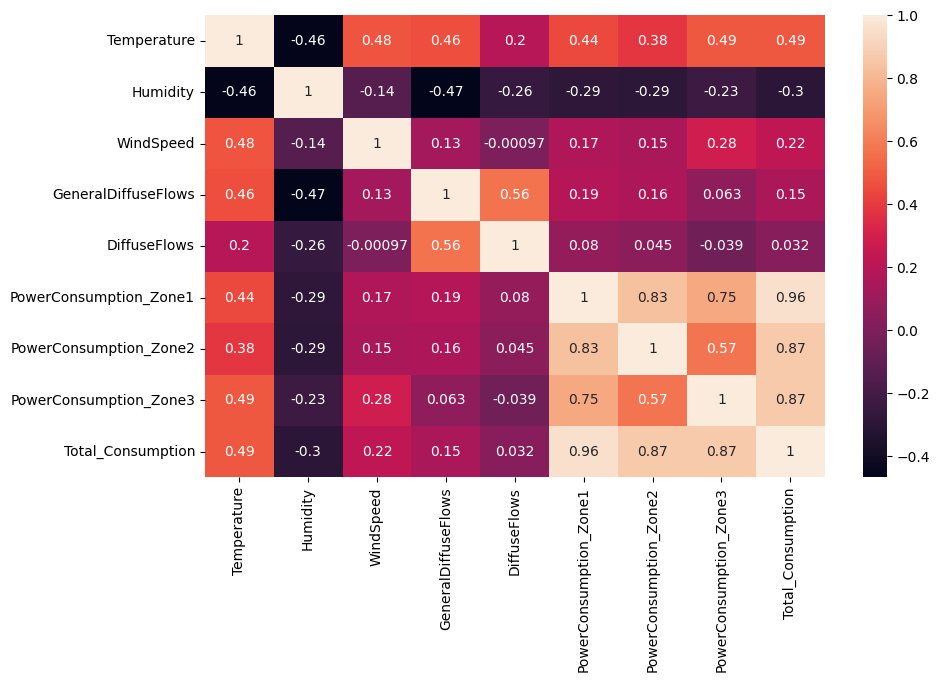

In [12]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [13]:
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month
df["day_of_week"] = df.index.dayofweek

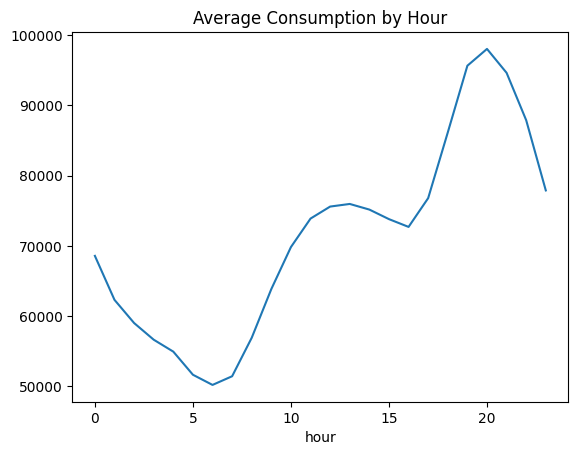

In [14]:
df.groupby("hour")["Total_Consumption"].mean().plot()
plt.title("Average Consumption by Hour")
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Total_Consumption"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -26.567629573251136
p-value: 0.0


In [16]:
df["lag_1"] = df["Total_Consumption"].shift(1)
df["lag_24"] = df["Total_Consumption"].shift(24)
df["rolling_mean_24"] = df["Total_Consumption"].rolling(24).mean()

df.dropna(inplace=True)

In [17]:
X = df.drop("Total_Consumption", axis=1)
y = df["Total_Consumption"]

In [18]:
split = int(len(df)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [19]:
!pip install xgboost

In [20]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [21]:
predictions = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 562.4297206500144
RMSE: 768.0662946702093


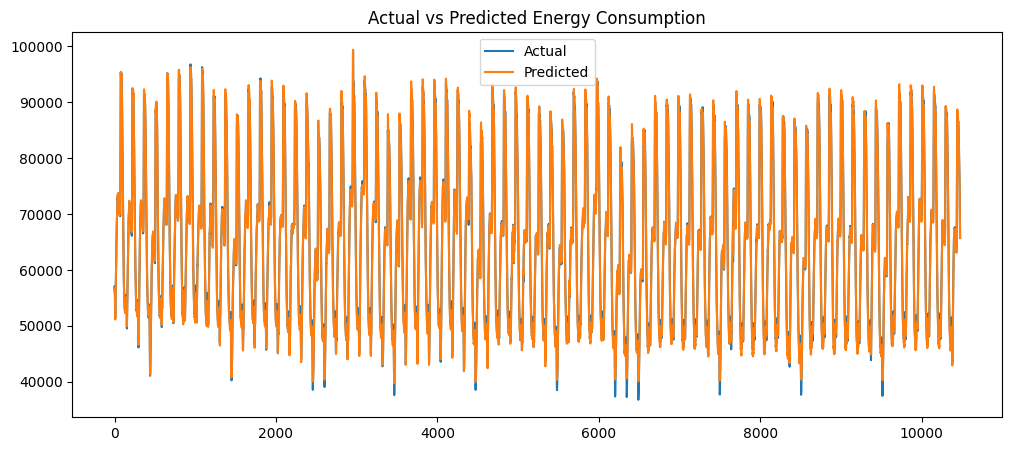

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

In [24]:
model.score(X_test, y_test)

0.9970378014974179

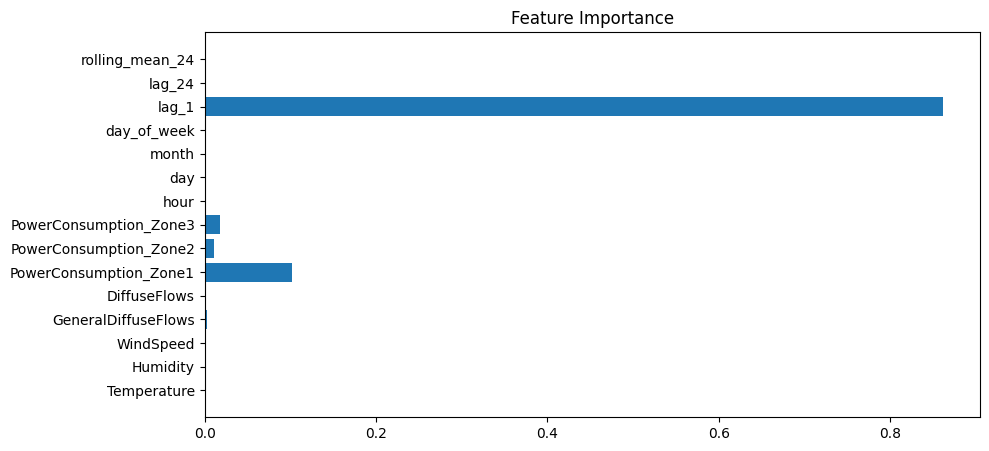

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()

In [26]:
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
print("MAPE:", mape)

MAPE: 0.925797690938125


In [27]:
baseline_pred = y_test.shift(1)

baseline_mae = mean_absolute_error(y_test[1:], baseline_pred[1:])
print("Baseline MAE:", baseline_mae)

Baseline MAE: 787.6797504548578


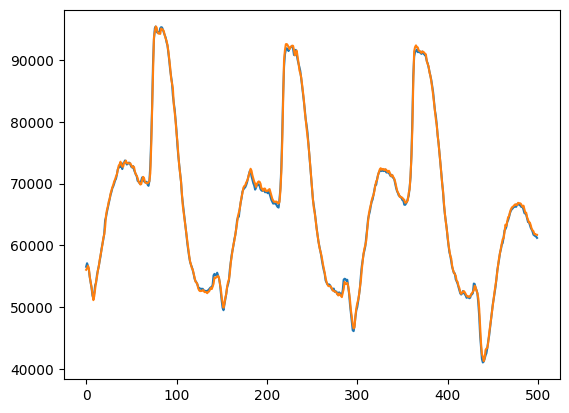

In [28]:
plt.plot(y_test.values[:500])
plt.plot(predictions[:500])

In [29]:
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, predictions)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train MAE: 265.6562594576862
Test MAE: 562.4297206500144


In [30]:
df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Total_Consumption,hour,day,month,day_of_week,lag_1,lag_24,rolling_mean_24
count,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000,52392.000000
mean,18.816143,68.255438,1.960349,182.780277,75.062336,32348.707453,21045.087497,17835.920039,71229.714989,11.504581,15.685295,6.513514,2.998626,71229.374666,71219.231254,71224.610566
std,5.809763,15.553535,2.349056,264.432609,124.229046,7129.671533,5201.095268,6623.534303,17143.450811,6.920486,8.768201,3.439407,1.999446,17143.736559,17145.679759,15848.561680
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070,36785.039739,0.000000,1.000000,1.000000,0.000000,36785.039739,36785.039739,42069.265560
25%,14.420000,58.300000,0.078000,0.062000,0.122000,26318.259343,16982.926830,13126.210420,56506.037013,6.000000,8.000000,4.000000,1.000000,56505.625710,56494.977308,57577.789808
50%,18.790000,69.860000,0.086000,5.092500,4.511500,32271.342950,20826.476580,16415.962095,69792.507530,12.000000,16.000000,7.000000,3.000000,69792.507530,69785.206235,70445.541231
75%,22.900000,81.400000,4.915000,319.800000,101.025000,37313.960610,24716.710628,21627.609838,83764.735517,18.000000,23.000000,10.000000,5.000000,83764.735517,83748.452927,82451.938755
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360,134208.145950,23.000000,31.000000,12.000000,6.000000,134208.145950,134208.145950,126677.887594


In [31]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.5 MB/s eta 0:00:00


In [32]:
import joblib

# Save model to file
joblib.dump(model, "energy_model1.pkl")

print("Model saved successfully!")

Model saved successfully!


In [33]:
!pip install streamlit pyngrok

In [34]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

model = joblib.load("energy_model.pkl")

st.title("⚡ Smart Energy Consumption Forecasting")

temperature = st.number_input("Temperature", value=20.0)
humidity = st.number_input("Humidity", value=60.0)
windspeed = st.number_input("Wind Speed", value=2.0)

hour = st.slider("Hour", 0, 23, 12)
day = st.slider("Day", 1, 31, 15)
month = st.slider("Month", 1, 12, 6)
day_of_week = st.slider("Day of Week", 0, 6, 3)

lag_1 = st.number_input("Previous Hour Consumption", value=70000.0)
lag_24 = st.number_input("Previous Day Same Hour", value=68000.0)

if st.button("Predict"):
    features = np.array([[temperature, humidity, windspeed,
                          hour, day, month, day_of_week,
                          lag_1, lag_24]])

    prediction = model.predict(features)
    st.success(f"Predicted Consumption: {prediction[0]:.2f}")

Writing app.py


In [35]:
print(X_train.columns)

Index(['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
       'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2',
       'PowerConsumption_Zone3', 'hour', 'day', 'month', 'day_of_week',
       'lag_1', 'lag_24', 'rolling_mean_24'],
      dtype='object')


In [36]:
from pyngrok import ngrok

ngrok.set_auth_token("39yCrVJQUx46yNlzkl5e3OTiIIL_4Dj6nhYwD7uEPVaM2bt9A")

In [37]:
from pyngrok import ngrok

# Kill old tunnels
ngrok.kill()

# Start Streamlit in background
!streamlit run app.py &>/dev/null &

# Create public URL
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://loni-unarbitrative-maya.ngrok-free.dev" -> "http://localhost:8501"
